In [1]:
import os
HOME = os.getcwd()
print(HOME)

C:\Users\Merle\PycharmProjects\AIChickenCoop\ImgLabelling


In [2]:
VIDEO_DIR_PATH = f"{HOME}/TestVids"
IMAGE_DIR_PATH = f"{HOME}/TestImgs"
FRAME_STRIDE = 60

In [3]:
import supervision as sv
from tqdm import tqdm
 
video_paths = sv.list_files_with_extensions(
    directory=VIDEO_DIR_PATH,
    extensions=["mov", "mp4"])
print(video_paths)
TRAIN_VIDEO_PATHS = video_paths

for video_path in tqdm(TRAIN_VIDEO_PATHS):
    print(f"Saving images to {IMAGE_DIR_PATH}")
    video_name = video_path.stem
    image_name_pattern = video_name + "-{:05d}.png"
    print(f"Pattern: {image_name_pattern}")
    with sv.ImageSink(target_dir_path=IMAGE_DIR_PATH, image_name_pattern=image_name_pattern) as sink:
        for image in sv.get_video_frames_generator(source_path=str(video_path), stride=FRAME_STRIDE):
            sink.save_image(image=image)



[WindowsPath('C:/Users/Merle/PycharmProjects/AIChickenCoop/ImgLabelling/TestVids/SmallTest1.mp4'), WindowsPath('C:/Users/Merle/PycharmProjects/AIChickenCoop/ImgLabelling/TestVids/SmallTest2.mp4'), WindowsPath('C:/Users/Merle/PycharmProjects/AIChickenCoop/ImgLabelling/TestVids/SmallTest3.mp4'), WindowsPath('C:/Users/Merle/PycharmProjects/AIChickenCoop/ImgLabelling/TestVids/SmallTest4.mp4'), WindowsPath('C:/Users/Merle/PycharmProjects/AIChickenCoop/ImgLabelling/TestVids/SmallTest5.mp4')]


  0%|          | 0/5 [00:00<?, ?it/s]

Saving images to C:\Users\Merle\PycharmProjects\AIChickenCoop\ImgLabelling/TestImgs2
Pattern: SmallTest1-{:05d}.png


 20%|██        | 1/5 [00:13<00:54, 13.59s/it]

Saving images to C:\Users\Merle\PycharmProjects\AIChickenCoop\ImgLabelling/TestImgs2
Pattern: SmallTest2-{:05d}.png


...

 60%|██████    | 3/5 [00:42<00:28, 14.15s/it]

Saving images to C:\Users\Merle\PycharmProjects\AIChickenCoop\ImgLabelling/TestImgs2
Pattern: SmallTest4-{:05d}.png


 80%|████████  | 4/5 [00:57<00:14, 14.56s/it]

Saving images to C:\Users\Merle\PycharmProjects\AIChickenCoop\ImgLabelling/TestImgs2
Pattern: SmallTest5-{:05d}.png


100%|██████████| 5/5 [01:11<00:00, 14.37s/it]


In [5]:
image_paths = sv.list_files_with_extensions(
    directory=IMAGE_DIR_PATH,
    extensions=["png", "jpg", "jpg"])

print('image count:', len(image_paths))

image count: 455


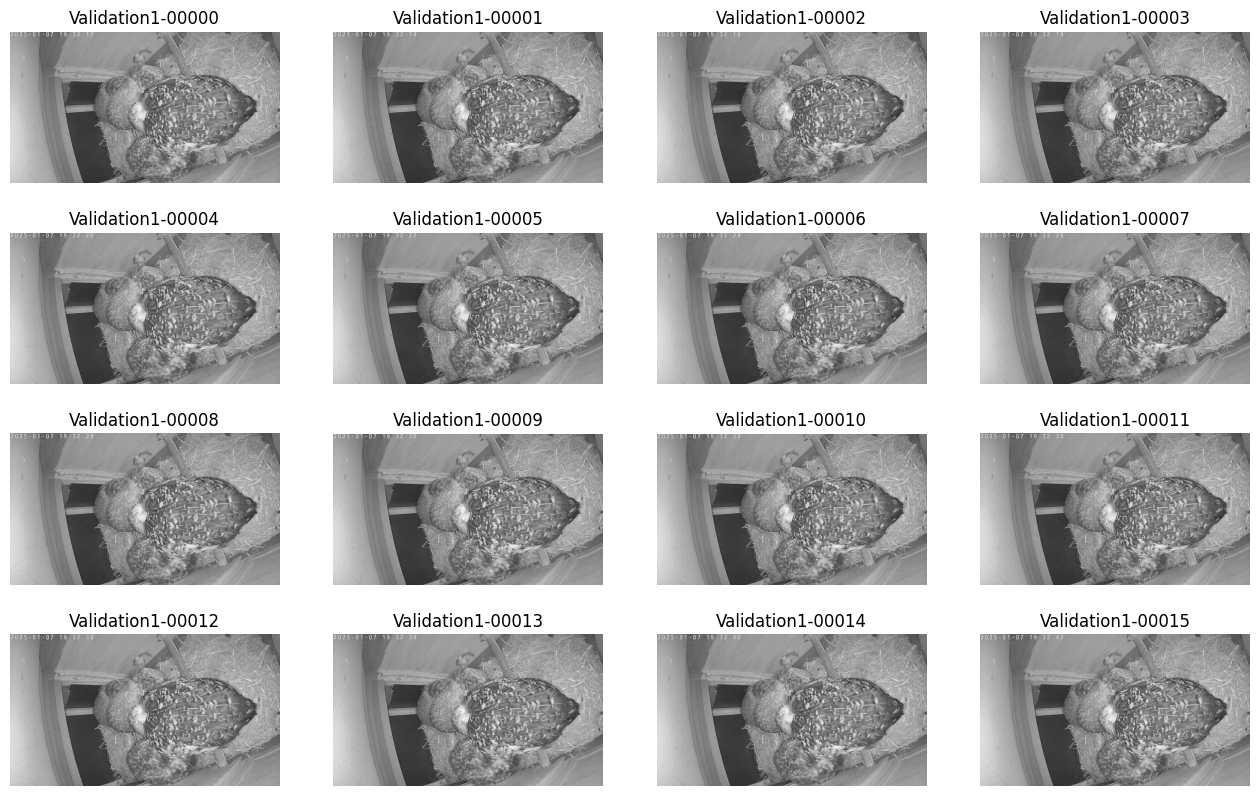

In [9]:


IMAGE_DIR_PATH = f"{HOME}/TestImgs"
SAMPLE_SIZE = 16
SAMPLE_GRID_SIZE = (4, 4)
SAMPLE_PLOT_SIZE = (16, 10)


import cv2


titles = [
    image_path.stem
    for image_path
    in image_paths[:SAMPLE_SIZE]]
images = [
    cv2.imread(str(image_path))
    for image_path
    in image_paths[:SAMPLE_SIZE]]

sv.plot_images_grid(images=images, titles=titles, grid_size=SAMPLE_GRID_SIZE, size=SAMPLE_PLOT_SIZE)



In [10]:
from autodistill.detection import CaptionOntology

ontology=CaptionOntology({
    "Chicken": "bird"
})
DATASET_DIR_PATH = f"{HOME}/TestDataset"

In [11]:
from autodistill_grounded_sam import GroundedSAM


base_model = GroundedSAM(ontology=ontology)
dataset = base_model.label(
    input_folder=IMAGE_DIR_PATH,
    extension=".png",
    output_folder=DATASET_DIR_PATH)



trying to load grounding dino directly
final text_encoder_type: bert-base-uncased


Labeling C:\Users\Merle\PycharmProjects\AIChickenCoop\ImgLabelling/ValidationImgs\Validation1-00000.png:   0%|          | 0/455 [00:00<?, ?it/s]The `device` argument is deprecated and will be removed in v5 of Transformers.
torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
None of the inputs have requires_grad=True. Gradients will be None
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
Labeling C:\Users\Merle\PycharmProjects\AIChickenCoop\ImgLabelling/ValidationImgs\Validation5-00090.png: 100%|██████████| 455/455 [18:03<00:00,  2.38s/it]


Labeled dataset created - ready for distillation.


In [12]:


ANNOTATIONS_DIRECTORY_PATH = f"{HOME}/TestDataset/train/labels"
IMAGES_DIRECTORY_PATH = f"{HOME}/TestDataset/train/images"
DATA_YAML_PATH = f"{HOME}/TestDataset/data.yaml"



In [13]:
import supervision as sv

dataset = sv.DetectionDataset.from_yolo(
    images_directory_path=IMAGES_DIRECTORY_PATH,
    annotations_directory_path=ANNOTATIONS_DIRECTORY_PATH,
    data_yaml_path=DATA_YAML_PATH)

len(dataset)

251

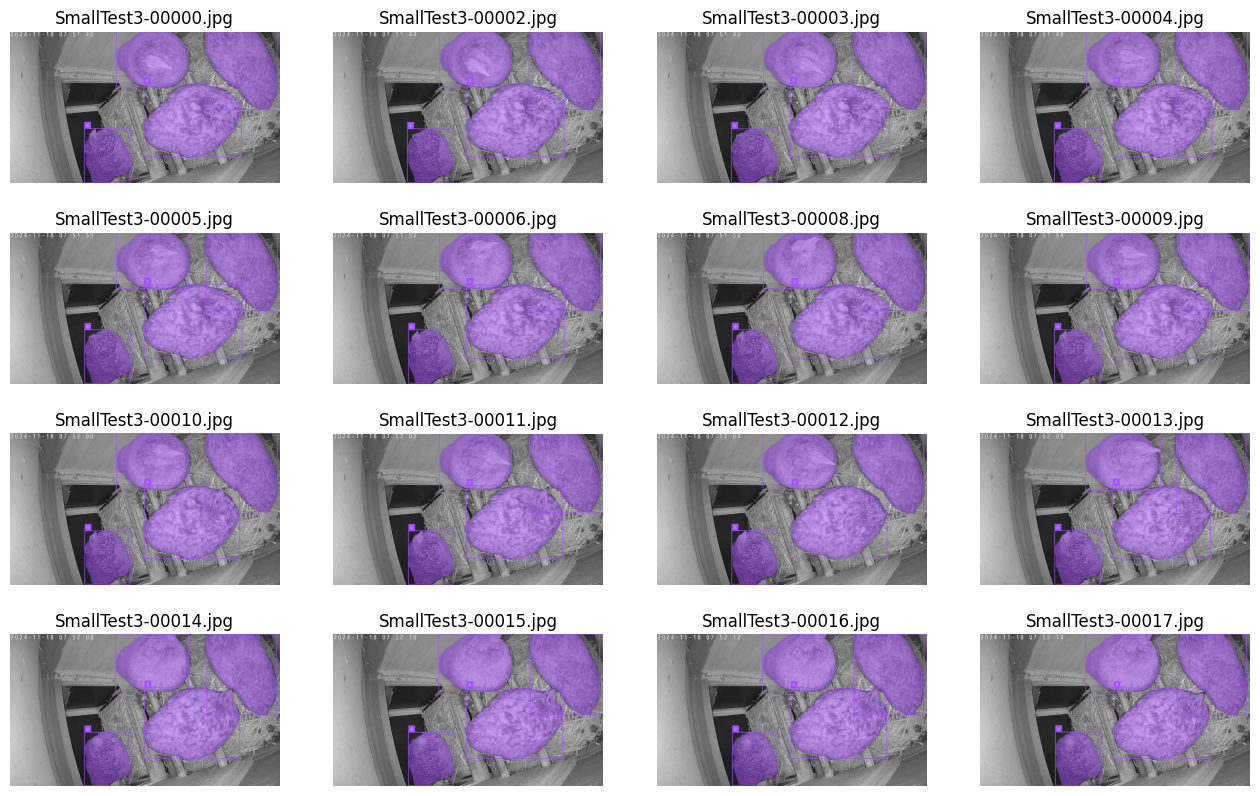

In [14]:
import supervision as sv
from pathlib import Path


mask_annotator = sv.MaskAnnotator()
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

images = []
image_names = []
for i, (image_path, image, annotation) in enumerate(dataset):
    if i == SAMPLE_SIZE:
        break
    annotated_image = image.copy()
    annotated_image = mask_annotator.annotate(
        scene=annotated_image, detections=annotation)
    annotated_image = box_annotator.annotate(
        scene=annotated_image, detections=annotation)
    annotated_image = label_annotator.annotate(
        scene=annotated_image, detections=annotation)

    image_names.append(Path(image_path).name)
    images.append(annotated_image)

sv.plot_images_grid(
    images=images,
    titles=image_names,
    grid_size=SAMPLE_GRID_SIZE,
    size=SAMPLE_PLOT_SIZE)